In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    fowlkes_mallows_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    confusion_matrix
)
from umap import UMAP
import sklearn
import seaborn as sns
from process import SpaHDSRL
import warnings
warnings.filterwarnings('ignore')
random_seed = 20

In [ ]:
file_fold = './tutorial1/'   #please replace 'file_fold' with the download path

adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ADT.h5ad')

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

In [ ]:
SpaHDSRL_result = SpaHDSRL(adata1=adata_omics1,adata2=adata_omics2)
SpaHDSRL_result.preprocessing_data(do_norm=True, n_neighbors = 5)
SpaHDSRL_result.train(spatial_regularization_strength=0.07, z_dim=50, 
         lr=1e-3, wnn_epoch = 500, total_epoch=300, max_patience_bef=10, max_patience_aft=30, min_stop=200, 
         random_seed=random_seed, gpu=0, regularization_acceleration=True, edge_subset_sz=1000000, k_neighbors=5, gamma=0.05)
df_embedding = pd.DataFrame(SpaHDSRL_result.embedding)

Epoch 1/300, Loss: 1.3963913917541504
Epoch 11/300, Loss: 1.2424821853637695
Epoch 21/300, Loss: 1.028038740158081
Epoch 31/300, Loss: 0.8333429098129272
Epoch 41/300, Loss: 0.7132390737533569
Epoch 51/300, Loss: 0.5030174851417542
Epoch 61/300, Loss: 0.7176519632339478
Epoch 71/300, Loss: 0.2729359269142151
Epoch 81/300, Loss: 0.2018698751926422
Epoch 91/300, Loss: 0.14356933534145355
Epoch 101/300, Loss: 0.11386112868785858
Epoch 111/300, Loss: 0.09200344234704971
Epoch 121/300, Loss: 0.18883827328681946
Epoch 131/300, Loss: 0.1290750354528427
Epoch 141/300, Loss: 0.11522145569324493
Epoch 151/300, Loss: 0.08489520847797394
Epoch 161/300, Loss: 0.07131843268871307
Epoch 171/300, Loss: 0.05717640370130539
Epoch 181/300, Loss: 0.04937892407178879
Epoch 191/300, Loss: 0.04481612145900726
Epoch 201/300, Loss: 0.04280286282300949
Epoch 211/300, Loss: 0.0370672233402729
Epoch 221/300, Loss: 0.037014707922935486
Epoch 231/300, Loss: 0.032343488186597824
Epoch 241/300, Loss: 0.02975555695593

In [4]:
def screen_res(df_embedding, n_cluster = 5, res_s = 0.1, res_e = 1.0, step = 0.1):
    opt_res = res_s
    opt_clusters = n_cluster
    for res in np.arange(res_s,res_e,step):
        embedding_adata = sc.AnnData(df_embedding)
        sc.pp.neighbors(embedding_adata, n_neighbors=50, use_rep='X')
        sc.tl.leiden(embedding_adata, resolution=float(res))
        clusters = list(embedding_adata.obs["leiden"])
        cluster_num = len(np.unique(clusters))
        print('res = ' + str(round(res, 2)) + ', Cluster# = ' + str(cluster_num))
        if cluster_num == n_cluster:
            opt_res = res
            opt_clusters = clusters
    print('optimal res = ' + str(round(opt_res, 2)))
    return opt_res, opt_clusters

opt_res_SpaHDSRL, opt_clusters_SpaHDSRL = screen_res(df_embedding,res_s = 0.0, res_e = 1.0, step = 0.02,n_cluster = 5)

res = 0.0, Cluster# = 1
res = 0.02, Cluster# = 3
res = 0.04, Cluster# = 4
res = 0.06, Cluster# = 5
res = 0.08, Cluster# = 5
res = 0.1, Cluster# = 5
res = 0.12, Cluster# = 5
res = 0.14, Cluster# = 5
res = 0.16, Cluster# = 5
res = 0.18, Cluster# = 5
res = 0.2, Cluster# = 6
res = 0.22, Cluster# = 6
res = 0.24, Cluster# = 6
res = 0.26, Cluster# = 6
res = 0.28, Cluster# = 6
res = 0.3, Cluster# = 6
res = 0.32, Cluster# = 6
res = 0.34, Cluster# = 6
res = 0.36, Cluster# = 6
res = 0.38, Cluster# = 6
res = 0.4, Cluster# = 7
res = 0.42, Cluster# = 7
res = 0.44, Cluster# = 7
res = 0.46, Cluster# = 7
res = 0.48, Cluster# = 7
res = 0.5, Cluster# = 7
res = 0.52, Cluster# = 7
res = 0.54, Cluster# = 7
res = 0.56, Cluster# = 7
res = 0.58, Cluster# = 7
res = 0.6, Cluster# = 8
res = 0.62, Cluster# = 7
res = 0.64, Cluster# = 8
res = 0.66, Cluster# = 9
res = 0.68, Cluster# = 9
res = 0.7, Cluster# = 9
res = 0.72, Cluster# = 9
res = 0.74, Cluster# = 9
res = 0.76, Cluster# = 9
res = 0.78, Cluster# = 9
res = 0.

In [5]:
# add ground truth
adata = adata_omics1
adata.obs['ground_truth'] = 1*np.array(adata.obsm['spfac'][:,0] + 2*adata.obsm['spfac'][:,1] + 3*adata.obsm['spfac'][:,2] + 4*adata.obsm['spfac'][:,3])
adata.obs['annotation'] = adata.obs['ground_truth']
adata.obs['annotation'].replace({1.0:'factor1',
                                   2.0:'factor2',
                                   3.0:'factor3',
                                   4.0:'factor4',
                                   0.0:'backgr'  
                                              }, inplace=True)

list_ = ['factor1','factor2','factor3','factor4','backgr']
adata.obs['annotation']  = pd.Categorical(adata.obs['annotation'], 
                      categories=list_,
                      ordered=True)

In [6]:
adata_new = adata_omics1.copy()
adata_new.obs['Cluster_SpaHDSRL'] = opt_clusters_SpaHDSRL
adata_new.obs["Cluster_SpaHDSRL"]=adata_new.obs["Cluster_SpaHDSRL"].astype('category')

common = adata_omics1.obs_names.intersection(adata_new.obs_names)
gt_all = adata_omics1[common].obs["annotation"].astype(str).values
pred_all = adata_new[common].obs["Cluster_SpaHDSRL"].astype(str).values

def compute_metrics(gt, pred, name="ALL"):
    out = {}
    out["ARI"] = adjusted_rand_score(gt, pred)
    out["NMI"] = normalized_mutual_info_score(gt, pred)
    out["AMI"] = adjusted_mutual_info_score(gt, pred)
    out["FMI"] = fowlkes_mallows_score(gt, pred)
    out["Homogeneity"] = homogeneity_score(gt, pred)
    out["Completeness"] = completeness_score(gt, pred)
    out["V-measure"] = v_measure_score(gt, pred)
    return pd.Series(out, name=name)


res_all = compute_metrics(gt_all, pred_all, name="include_backgr")
print(pd.concat([res_all], axis=1))


try:
    from scipy.optimize import linear_sum_assignment
    from sklearn.metrics import accuracy_score, f1_score

    def best_map_accuracy_f1(gt, pred):
        gt_labels = pd.unique(gt)
        pred_labels = pd.unique(pred)
        cm = confusion_matrix(gt, pred, labels=gt_labels)
        r, c = linear_sum_assignment(-cm)
        mapping = {pred_labels[c[i]]: gt_labels[r[i]] for i in range(len(r))}
        pred_mapped = np.array([mapping.get(x, x) for x in pred], dtype=object)

        acc = accuracy_score(gt, pred_mapped)
        f1m = f1_score(gt, pred_mapped, average="macro")
        f1w = f1_score(gt, pred_mapped, average="weighted")
        return acc, f1m, f1w, mapping

    acc_all, f1m_all, f1w_all, mp_all = best_map_accuracy_f1(gt_all, pred_all)
    print("\nBest-matched (include backgr): ACC=", acc_all, " macroF1=", f1m_all, " weightedF1=", f1w_all)
    print("mapping:", mp_all)

except ImportError:
    print("pip install scipy")


              include_backgr
ARI                 0.884793
NMI                 0.886992
AMI                 0.886537
FMI                 0.910770
Homogeneity         0.887979
Completeness        0.886007
V-measure           0.886992

Best-matched (include backgr): ACC= 0.9575617283950617  macroF1= 0.9607192168458394  weightedF1= 0.9573035076734207
mapping: {'1': 'factor2', '4': 'factor1', '2': 'factor3', '3': 'factor4', '0': 'backgr'}


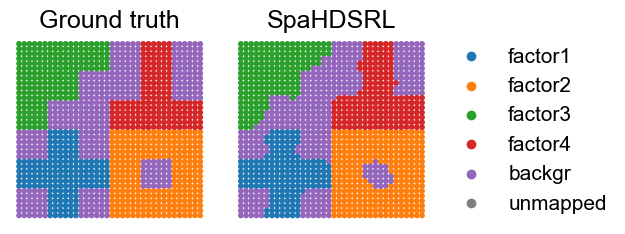

In [7]:
mapping = {'1': 'factor2', '4': 'factor1', '2': 'factor3', '3': 'factor4', '0': 'backgr'}
common = adata_omics1.obs_names.intersection(adata_new.obs_names)
adata_gt = adata_omics1[common].copy()
adata_pr = adata_new[common].copy()

gt_col = "annotation"

pred_raw = adata_pr.obs["Cluster_SpaHDSRL"].astype(str)
adata_pr.obs["Cluster_mapped"] = pred_raw.map(mapping).fillna("unmapped")


order = ["factor1", "factor2", "factor3", "factor4", "backgr", "unmapped"]
adata_gt.obs[gt_col] = pd.Categorical(adata_gt.obs[gt_col].astype(str), categories=order, ordered=True)
adata_pr.obs["Cluster_mapped"] = pd.Categorical(adata_pr.obs["Cluster_mapped"], categories=order, ordered=True)


palette = {
    "factor1": "#1f77b4",  
    "factor2": "#ff7f0e",  
    "factor3": "#2ca02c",  
    "factor4": "#d62728",  
    "backgr":  "#9467bd",  
    "unmapped":"#7f7f7f"   
}


plt.rcParams["font.size"] = 15
plt.rcParams["font.sans-serif"] = "Arial"

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.6))  

# Left：Ground truth
sc.pl.embedding(
    adata_gt, basis="spatial", color=gt_col, palette=palette,
    s=70, title="Ground truth", show=False, ax=axes[0], legend_loc=None
)
axes[0].axis("off")
axes[0].invert_yaxis()

# Right：SpaHDSRL
sc.pl.embedding(
    adata_pr, basis="spatial", color="Cluster_mapped", palette=palette,
    s=70, title="SpaHDSRL", show=False, ax=axes[1]
)
axes[1].axis("off")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

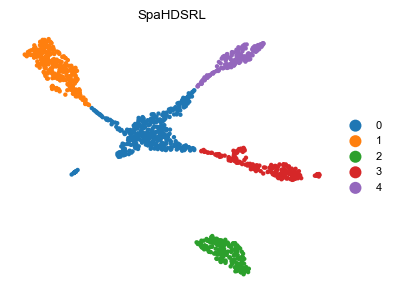

In [8]:
# UMAP visualization
umap_2d = UMAP(n_components=2, init='random', random_state=random_seed, min_dist = 0.3,n_neighbors=30)
umap_pos = umap_2d.fit_transform(df_embedding)
adata_new.obs['SpaHDSRL_umap_pos_x'] = umap_pos[:,0]
adata_new.obs['SpaHDSRL_umap_pos_y'] = umap_pos[:,1]

# Ploting figures
plot_color = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#bcbd22", "#17becf", "#ffbb78"
]
matplotlib.rcParams['font.size'] = 8.0
fig, axes = plt.subplots(1, 1, figsize=(4,3))
sz = 40
domains="Cluster_SpaHDSRL"
num_celltype=len(adata_new.obs[domains].unique())
adata_new.uns[domains+"_colors"]=list(plot_color[:num_celltype])
titles = 'SpaHDSRL'
ax=sc.pl.scatter(adata_new,alpha=1,x="SpaHDSRL_umap_pos_x",y="SpaHDSRL_umap_pos_y",color=domains,title=titles ,color_map=plot_color,show=False,size=sz,ax = axes)
ax.axis('off')
plt.tight_layout()